#Regresja liniowa

Regresja liniowa jest podstawowym modelem ekonometrycznym ale także podstawowym modelem uczenia maszynowego. Dla jednej zmiennej niezależnej szukamy prostej, która najlepiej opisuje zależność $Y$ od $X$:
$Y=aX+b$

a - współczynnik kierunkowy (nachylenie prostej)\
b - wyraz wolny (punkt przecięcia z osią Y, bias)\
Y - przewidywana wartość

Dla wielu zmiennych objaśniających:
$Y = b + β_1 X_1 + β_2 X_2 + \dots β_n X_n$

$Y=βX$,
gdzie:

$X$— macierz planu (zmienne-cechy z kolumną jedynek, jeśli model zawiera wyraz wolny),\
$β$ — wektor parametrów,\
$Y$ — wektor wartości zmiennej zależnej-zmiennej celu.

Wzór ogólny na wektor parametrów
${\beta}=(\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}$
wyprowadzany jest bezpośrednio przez minimalizację funkcji straty:

$S = \sum_{i=1}^n (y_i - \hat{y_i})^2$

Liczymy pochodne cząstkowe i przyrównujemy je do 0.
We wzorze mamy iloczyn macierzy $(\mathbf{X}^T \mathbf{X})^{-1}$.
Taka macierz ma wymiar równy liczbie zmiennych +1. Dla małych problemów można ją odwrócić. Dla danych o dużej liczbie zmiennych odwrócenie macierzy jest kosztowne. Złożoność obliczeniowa to $O(n^3)$, gdzie n-liczba zmiennych.


In [37]:
import numpy as np
import torch
import matplotlib.pyplot as plt

a_ref=-1.5
b_ref=8
noise=0.5*np.random.rand(50)

x=np.linspace(1,4,50)
y=a_ref*x + b_ref + noise

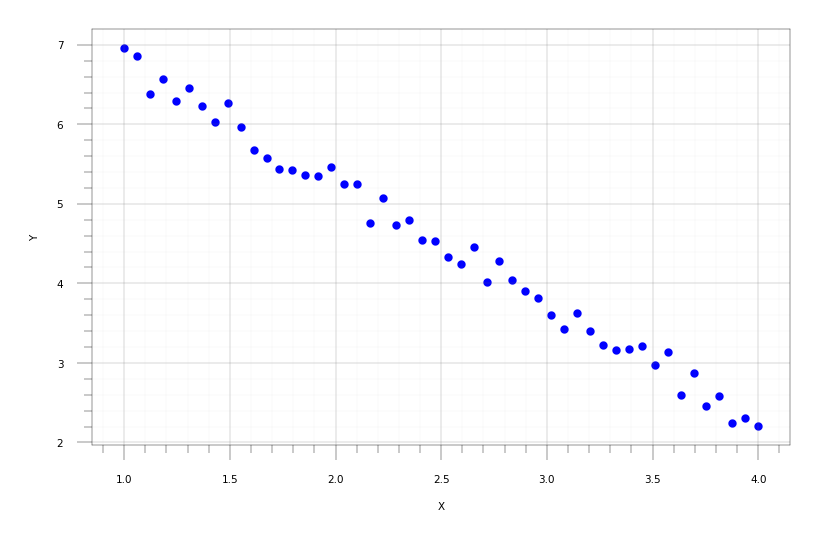

In [38]:
def plot(x,y):
    # Tworzy wykres całego zbioru niebieskim kolorem
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.scatter(x,y,s=1, color='blue')
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Y')
    plt.xlabel("X")
    # pokazuje wykres
    plt.show()
plot(x,y)

#Przykład 1 Wyznaczenie parametrów bezpośrednio ze wzorów

In [39]:
x_data = torch.Tensor(x).reshape(-1, 1)
y_data = torch.Tensor(y).reshape(-1, 1)
x_data

tensor([[1.0000],
        [1.0612],
        [1.1224],
        [1.1837],
        [1.2449],
        [1.3061],
        [1.3673],
        [1.4286],
        [1.4898],
        [1.5510],
        [1.6122],
        [1.6735],
        [1.7347],
        [1.7959],
        [1.8571],
        [1.9184],
        [1.9796],
        [2.0408],
        [2.1020],
        [2.1633],
        [2.2245],
        [2.2857],
        [2.3469],
        [2.4082],
        [2.4694],
        [2.5306],
        [2.5918],
        [2.6531],
        [2.7143],
        [2.7755],
        [2.8367],
        [2.8980],
        [2.9592],
        [3.0204],
        [3.0816],
        [3.1429],
        [3.2041],
        [3.2653],
        [3.3265],
        [3.3878],
        [3.4490],
        [3.5102],
        [3.5714],
        [3.6327],
        [3.6939],
        [3.7551],
        [3.8163],
        [3.8776],
        [3.9388],
        [4.0000]])

In [40]:
X=torch.cat([torch.ones(50,1),x_data],1) #dodajemy kolumnę jedynek (budujemy tzw. macierz planu)
X

tensor([[1.0000, 1.0000],
        [1.0000, 1.0612],
        [1.0000, 1.1224],
        [1.0000, 1.1837],
        [1.0000, 1.2449],
        [1.0000, 1.3061],
        [1.0000, 1.3673],
        [1.0000, 1.4286],
        [1.0000, 1.4898],
        [1.0000, 1.5510],
        [1.0000, 1.6122],
        [1.0000, 1.6735],
        [1.0000, 1.7347],
        [1.0000, 1.7959],
        [1.0000, 1.8571],
        [1.0000, 1.9184],
        [1.0000, 1.9796],
        [1.0000, 2.0408],
        [1.0000, 2.1020],
        [1.0000, 2.1633],
        [1.0000, 2.2245],
        [1.0000, 2.2857],
        [1.0000, 2.3469],
        [1.0000, 2.4082],
        [1.0000, 2.4694],
        [1.0000, 2.5306],
        [1.0000, 2.5918],
        [1.0000, 2.6531],
        [1.0000, 2.7143],
        [1.0000, 2.7755],
        [1.0000, 2.8367],
        [1.0000, 2.8980],
        [1.0000, 2.9592],
        [1.0000, 3.0204],
        [1.0000, 3.0816],
        [1.0000, 3.1429],
        [1.0000, 3.2041],
        [1.0000, 3.2653],
        [1.0

In [41]:
A=np.linalg.inv(X.T @ X) @ X.T @ y_data
A

tensor([[ 8.2907],
        [-1.5196]])

Otrzymaliśmy parametry modelu b=8.33706622 oraz a=-1.51424067

## Przykład 2. Ręczne liczenie gradientów.

### Sztuczne dane generowane pod model regresji liniowej

In [42]:
import numpy as np
import torch

a_ref=-1.5
b_ref=8
noise=0.5*np.random.rand(50)

x=np.linspace(1,4,50)
y=a_ref*x + b_ref + noise

### Wizualizacja danych

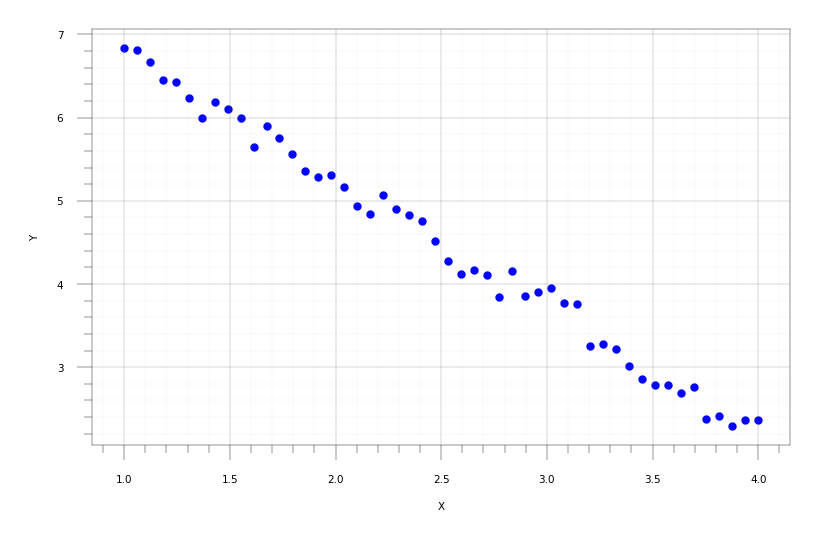

In [43]:
import matplotlib.pyplot as plt

def plot(x,y):
    # Tworzy wykres całego zbioru niebieskim kolorem
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.scatter(x,y,s=1, color='blue')
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Y')
    plt.xlabel("X")
    # pokazuje wykres
    plt.show()
plot(x,y)

## Opis algorytmu

#### Krok 0 - Losowa inicjalizacja parametrów "b" i "a"
   np.random.seed(42)\
   b = np.random.randn(1)\
   a = np.random.randn(1)\
\
   print(b,a)

#### Krok 1 - Wyznaczamy wartości przewidywane przez model-krok do przodu/propagacja w przód - forward pass
      y_pred = b + a * x

#### Krok 2 - Obliczanie straty
Używamy WSZYSTKICH punktów danych, więc jest to  
podstawowy spadek gradientowy na całym zbiorze, tzw batch gradient descent lub vanilla gradient descent.

 Jak błędny/niedokładny jest nasz model? To jest błąd!

     error = (y_pred - y)

#### To jest regresja, więc liczymy błąd średniokwadratowy (MSE)
loss = (error ** 2).mean()

    print(loss)

#### Krok 3 - Obliczamy gradienty parametrów "b" i "a".
b_grad = 2 * error.mean()\
a_grad = 2 * (x * error).mean()\
print(b_grad, a_grad)\


In [44]:
#Przedstawiamy dane jako tensory  torch .tensors
xx = torch .tensor(x, dtype=torch.float32)
yy = torch .tensor(y, dtype=torch.float32)
#Inicjujemy wartości szukanych parametrów (wag modelu)
a = torch .tensor(1, requires_grad=False, dtype=torch.float32)
b = torch. tensor(5, requires_grad=False, dtype=torch.float32)

print(a)
print(b)

tensor(1.)
tensor(5.)


In [45]:
# Pętla ucząca (train)
numbOfEpoch = 10000
learning_rate = 0.1

loss0=[]
for ii in range(numbOfEpoch) :
    y_pred = a * xx + b
    error=(y_pred-yy)
    if ii>10:
        loss0.append(error.pow(2).mean())
    b_grad = 2*error.mean()
    a_grad =  2* (xx * error).mean()
    with torch.no_grad() :
        a = a - learning_rate * a_grad
        b = b - learning_rate * b_grad

print(a)
print (b)
print(error.mean())


tensor(-1.5367)
tensor(8.3209)
tensor(-2.0123e-06)


##Wizualizacja wyników

###Wykres *funkcji* straty

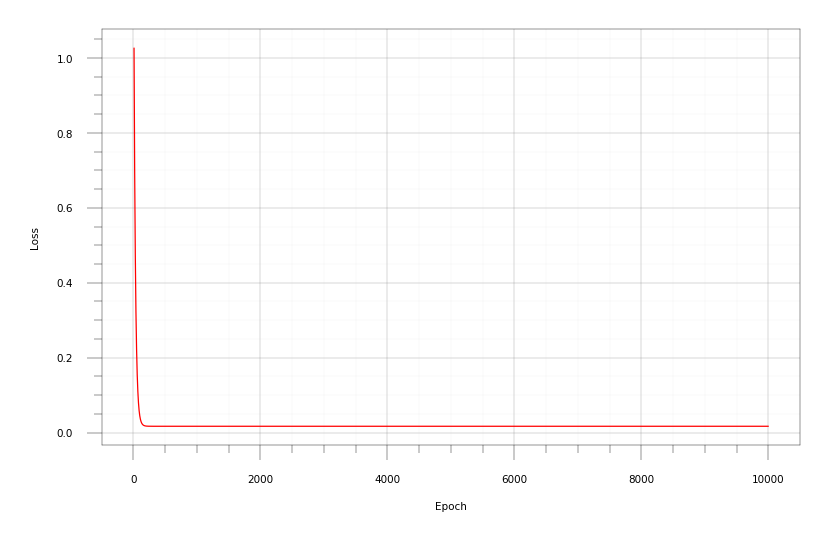

In [46]:
import matplotlib.pyplot as plt

def plot1(x,y):
    # punkty danych są niebieskie
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.plot(x,y, color='red',linewidth=0.3,alpha=1.)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Loss')
    plt.xlabel("Epoch")
    # pokazujemy wykres
    plt.show()

## wykres funkcji straty względem liczby epok
plot1(np.arange(10,len(loss0)+10),loss0)

###Wykres danych oraz wyznaczonej prostej regresji

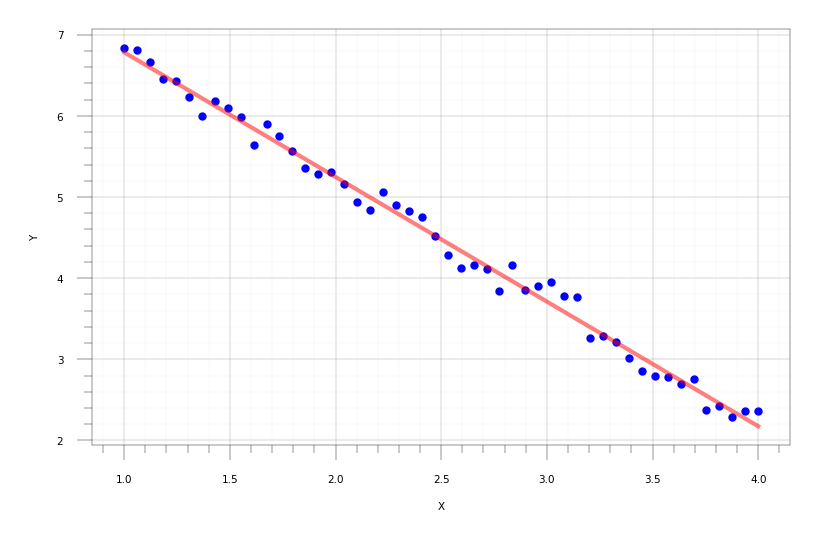

In [47]:
import matplotlib.pyplot as plt

def plot(x,y,ypred):
    # plot the entire dataset in blue
    ##plt.rcParams['font.size'] = 1.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.scatter(x,y,s=1, color='blue')
    plt.plot(x,ypred, color='red',linewidth=1,alpha=0.5)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Y')
    plt.xlabel("X")
    # show the plot
    plt.show()

a0=a.detach().numpy()
b0=b.detach().numpy()
y_pred = a0*x + b0
plot(x,y,y_pred)

## Przykład 3

### Korzystamy z tych samych generowanych danych

In [48]:
import torch
#dane przedstawiamy jako tensory
xx = torch .tensor(x, dtype=torch.float32)
yy = torch .tensor(y, dtype=torch.float32)
#Inicjujemy początkowe wartości parametrów modelu
a = torch .tensor(0, requires_grad=True, dtype=torch.float32)
b = torch. tensor(1, requires_grad=True, dtype=torch.float32)

def MSE_loss(pred,label):
    return (pred-label).pow(2).mean()
loss0=[]
# pętla ucząca
numbOfEpoch = 1000
learning_rate = 0.1
for ii in range(numbOfEpoch) :
    y_pred = a * xx + b
    loss = MSE_loss(pred=y_pred, label=yy)
    loss.backward( )
    if ii>10:
        loss0.append(loss)
    #Spadek grdientowy do aktualizacji parametrów
    with torch.no_grad( ) :
        a = a - learning_rate * a.grad
        b = b - learning_rate * b.grad
    a.requires_grad = True
    b.requires_grad = True

print(a)
print (b)
print(loss)

tensor(-1.5367, requires_grad=True)
tensor(8.3209, requires_grad=True)
tensor(0.0169, grad_fn=<MeanBackward0>)


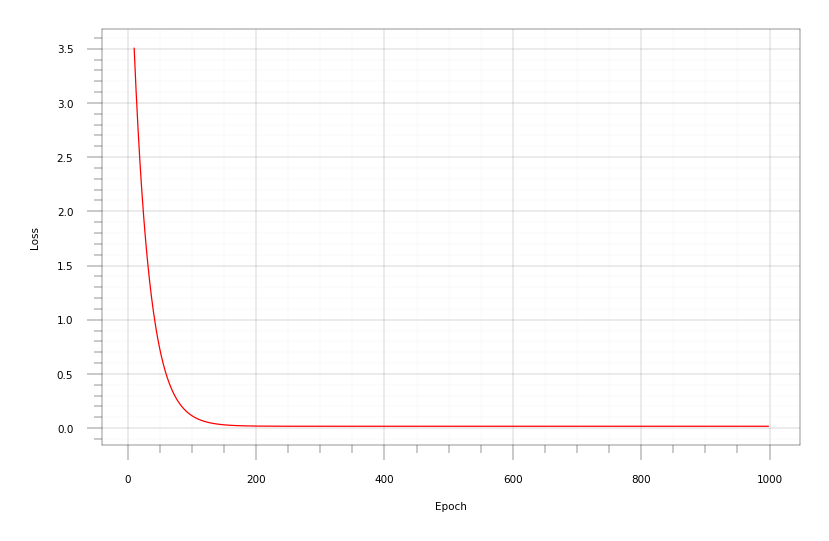

In [49]:
import matplotlib.pyplot as plt

def plot1(x,y):
    # plot the entire dataset in blue
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.plot(x,y, color='red',linewidth=0.3,alpha=1.)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Loss')
    plt.xlabel("Epoch")
    # show the plot
    plt.show()

## Loss versus epochs
plot1(np.arange(10,len(loss0)+10),torch.tensor(loss0).detach().numpy())

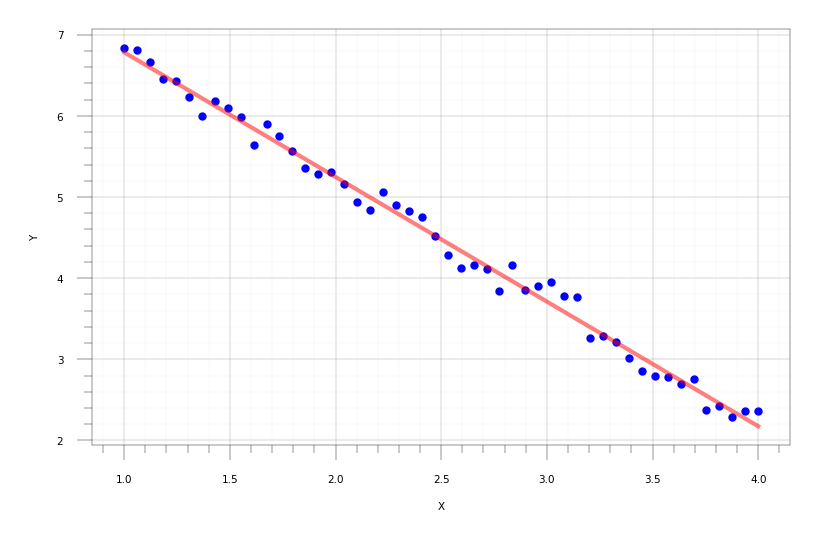

In [50]:

def plot(x,y,ypred):
    # plot the entire dataset in blue
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.scatter(x,y,s=1, color='blue')
    plt.plot(x,ypred, color='red',linewidth=1,alpha=0.5)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Y')
    plt.xlabel("X")
    # show the plot
    plt.show()

a0=a.detach().numpy()
b0=b.detach().numpy()
y_pred = a0*x + b0
plot(x,y,y_pred)

##Przykład 4

###  Budowa i estymacja modelu TORCH


1.	Wykorzystanie DataLoader do  pętli uczącej.
2.	Register criterion() using MSE and optimizer() using SGD
3.	Zresetowanie wszystkich gradientów do 0, wykonanie propagacji wstecznej, a następnie aktualizacja wag.
4.	Obliczenie predukcji

In [51]:
import torch
from torch.utils.data import DataLoader

## kontrola devices
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    # device='cpu'
print(f"Device used : {device}")

x_data = torch.Tensor(x).reshape(-1, 1)
y_data = torch.Tensor(y).reshape(-1, 1)

## set up loader to training set
## zip() czyta równolegle ze zbiorów
loader=DataLoader(list(zip(x_data,y_data)),shuffle=False,batch_size=8)

# our model
our_model=torch.nn.Sequential(
    torch.nn.Linear(1,10)).to(device)
print(our_model)

criterion = torch.nn.MSELoss(reduction='sum')
learning_rate = 0.01
optimizer = torch.optim.SGD(our_model.parameters(), lr = learning_rate)

loss0=[]
numbOfEpoch = 100
## uczenie modelu
our_model.train()
for epoch in range(numbOfEpoch) :
    #1 Krok w przód/propagacja w przód: Obliczamy przewidywane wartości y dla wartości x przekazancyh do modelu
    for x_batch,y_batch in loader:
        pred_y = our_model(x_batch.to(device))

        #2 Obliczenie straty
        loss = criterion(pred_y, y_batch.to(device))
        ## store loss to draw history
        if epoch>10:
            loss0.append(loss)

        #3 Zerowanie gradienów (poprzedniego kroku), propagacja wsteczna, czyli obliczenie nowych gradientów funkcji straty dla parametrów, dla których mamy requires_grad=True, aktualizacja wag.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

##predykcje modelu
our_model.eval()
pred_y = our_model(x_data.to(device))

print(loss.mean())

Device used : cuda
Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([8, 1])) that is different to the input size (torch.Size([8, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(8.7297, device='cuda:0', grad_fn=<MeanBackward0>)


## Wykres funkcji Loss w zależności od epochs

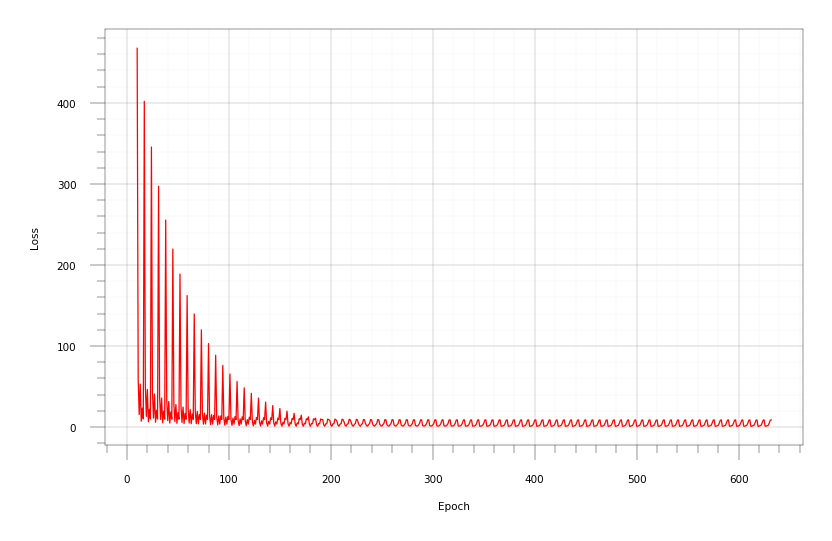

In [52]:
import matplotlib.pyplot as plt

def plot1(x,y):
    # plot the entire dataset in blue
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.plot(x,y, color='red',linewidth=0.3,alpha=1.)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Loss')
    plt.xlabel("Epoch")
    # show the plot
    plt.show()

## Loss versus epochs
plot1(np.arange(10,len(loss0)+10),torch.tensor(loss0).detach().numpy())

## Wyniki modelu

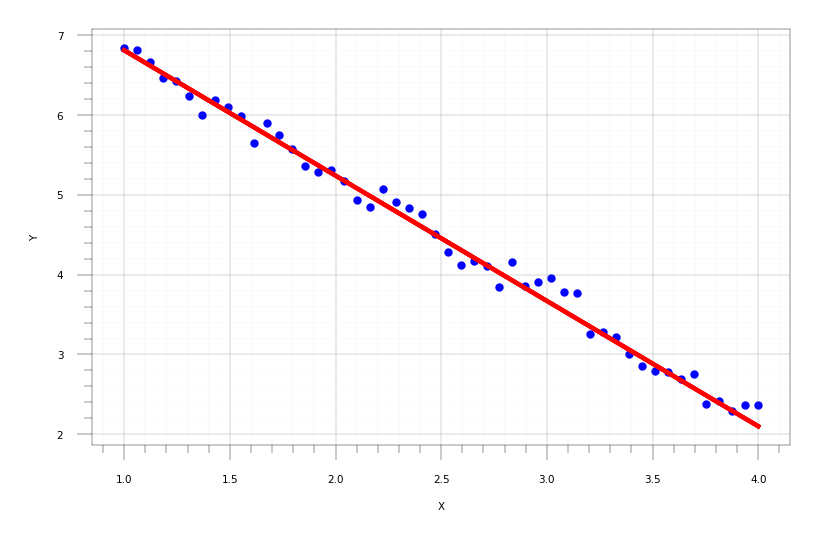

In [53]:
import matplotlib.pyplot as plt

def plot(x,y,ypred):
    # plot the entire dataset in blue
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.scatter(x,y,s=1, color='blue')
    plt.plot(x,ypred, color='red',linewidth=1,alpha=0.5)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Y')
    plt.xlabel("X")
    # show the plot
    plt.show()

plot(x,y,pred_y.cpu().detach().numpy())

##Przykład 5 Wykorzystanie modelu sieci neuronowych

###  Budowa i estymacja modelu regresji liniowej w oparciu o torch.nn.Module



1.	Wykonujemy propagację w przód i wyznaczamy predykcje modelu y.
2.	Obliczenie straty jako MSE.
3.	Zerujemy gradienty, wykonujemy propagację wsteczną, aktualizujemy wagi.


In [57]:
import torch

x_data = torch.Tensor(x).reshape(-1, 1)
y_data = torch.Tensor(y).reshape(-1, 1)


class LinearRegressionModel(torch.nn.Module):
     def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out
     def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

# model
our_model = LinearRegressionModel()

criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(our_model.parameters(), lr = 0.001)


loss0=[]
numbOfEpoch = 1000
learning_rate = 0.1
for epoch in range(numbOfEpoch) :
    #1 Propagacja w przód
    pred_y = our_model(x_data)

    #2 Obliczenie stratu
    loss = criterion(pred_y, y_data)
    if epoch>10:
        loss0.append(loss)

    #3 Zerowanie gradientów, propagacja wsteczna, aktualizacja wag.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

pred_y = our_model(x_data)
loss.mean()


tensor(0.8434, grad_fn=<MeanBackward0>)

## Wykres funkcji Loss w zależności od epochs

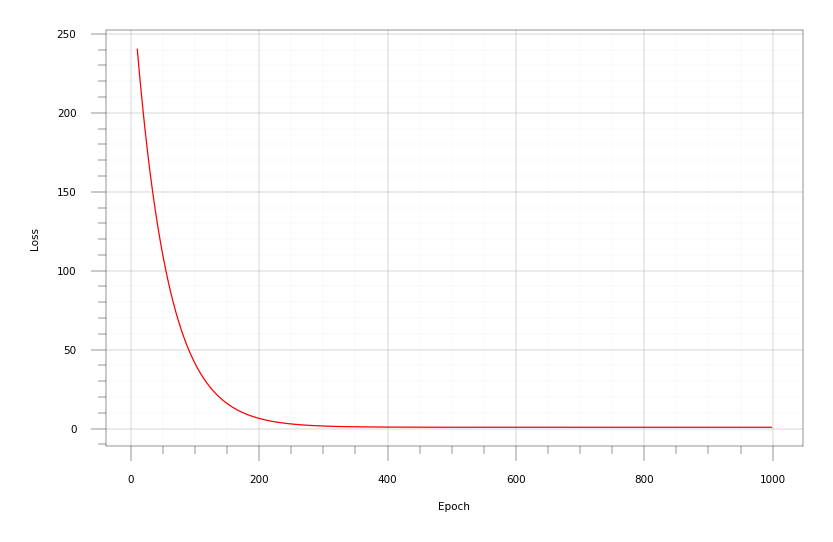

In [55]:
import matplotlib.pyplot as plt

def plot1(x,y):
    # plot the entire dataset in blue
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.plot(x,y, color='red',linewidth=0.3,alpha=1.)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Loss')
    plt.xlabel("Epoch")
    # show the plot
    plt.show()

## Loss versus epochs
plot1(np.arange(10,len(loss0)+10),torch.tensor(loss0).detach().numpy())

## Wyniki modelu

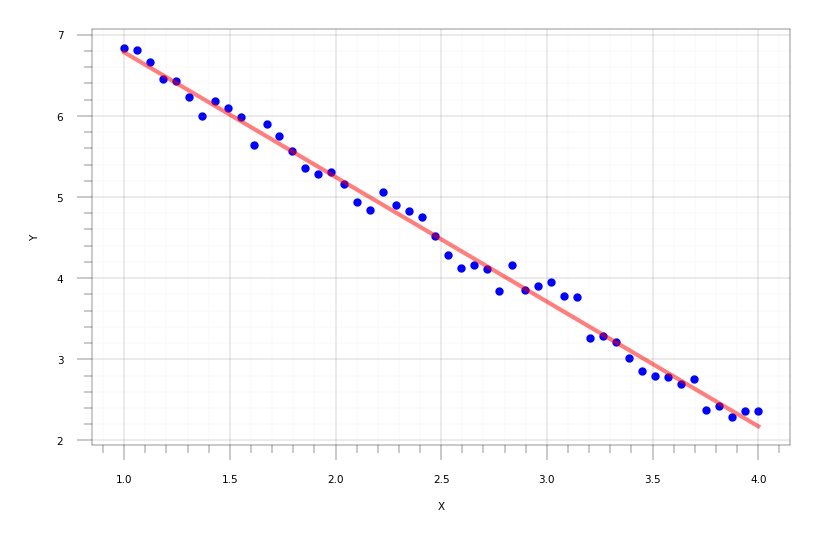

In [56]:
import matplotlib.pyplot as plt

def plot(x,y,ypred):
    # plot the entire dataset in blue
    plt.rcParams['font.size'] = 2.5
    fig, ax = plt.subplots(figsize=(3,1.8),dpi=300)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.1)
    ax.xaxis.set_tick_params(which='both',width=0.1)
    ax.yaxis.set_tick_params(which='both',width=0.1)
    plt.scatter(x,y,s=1, color='blue')
    plt.plot(x,ypred, color='red',linewidth=1,alpha=0.5)
    plt.grid(visible=True, which='major', color='#666666', linestyle='-',linewidth=0.06)
    plt.minorticks_on()
    plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.2,linewidth=0.06)
    plt.ylabel('Y')
    plt.xlabel("X")
    # show the plot
    plt.show()

plot(x,y,pred_y.detach().numpy())